##EDA - exploratory data analysis.

In this section we aim to check for any missing values or outliers while checking for any patterns like numerical or categorical relationships. We do this so that we can find which models are best suited for our dataset and which models will produce the best results in our analysis.

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df= pd.read_excel("/content/AB_NYC_2019.xlsx")

#first let's analyize the shape of the dataset and look into the first and last
#5 values of the dataset

print("shape of dataset:", df.shape)
print("\nfirst 5 rows:")
print(df.head())
print("\nlast 5 rows:")
print(df.tail())

#print data types
print("\n Data types:\n", df.dtypes)

shape of dataset: (48895, 16)

first 5 rows:
     id                                              name  host_id  \
0  2539                Clean & quiet apt home by the park     2787   
1  2595                             Skylit Midtown Castle     2845   
2  3647               THE VILLAGE OF HARLEM....NEW YORK !     4632   
3  3831                   Cozy Entire Floor of Brownstone     4869   
4  5022  Entire Apt: Spacious Studio/Loft by central park     7192   

     host_name neighbourhood_group neighbourhood  latitude  longitude  \
0         John            Brooklyn    Kensington  40.64749  -73.97237   
1     Jennifer           Manhattan       Midtown  40.75362  -73.98377   
2    Elisabeth           Manhattan        Harlem  40.80902  -73.94190   
3  LisaRoxanne            Brooklyn  Clinton Hill  40.68514  -73.95976   
4        Laura           Manhattan   East Harlem  40.79851  -73.94399   

         room_type  price  minimum_nights  number_of_reviews last_review  \
0     Private room 

id                                    0
name                                 19
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64


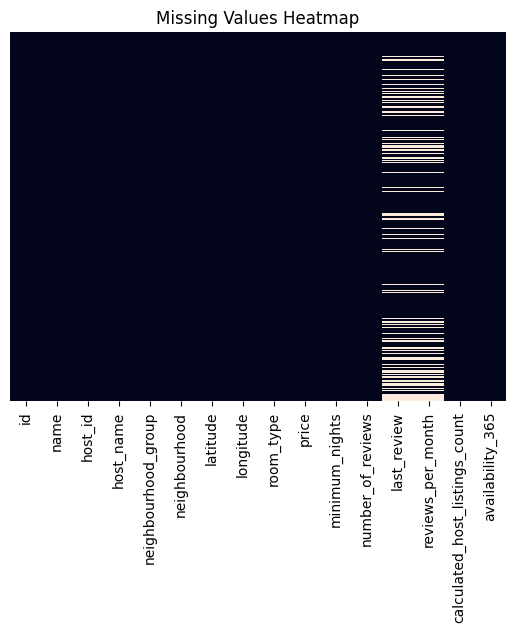

In [ ]:
#missing values
print(df.isnull().sum())
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title("Missing Values Heatmap")
plt.show()


This dataset containts 48,895 entires with 16 features. We se the following listing variables:

1. Price
2. id
3. name
4. host_id
5. host_name
6. neighbourhood_group
7. neighbourhood
8. latitude  
9. longitude
10. room_type
11. price
12. minimum_nights
13. number_of_reviews
14. last_review
15. reviews_per_month
16.calculated_host_listings_count
17. availability_365

We see a mix of numerical, categorical, text and date features. this suggests that we will need to preprocess some of the data (like encoding categorical variables) before applying any machine learning models.

For the missing value analysis we see that both last_review and reviews_per_month each have 10,052 missing values. This indicated that these missing values are likely due to listings with no reviews and we should either fill those missing values as a 0 or remove them depending modeling approach.


Summary statistics:
                 id       host_id      latitude     longitude         price  \
count  4.889500e+04  4.889500e+04  48895.000000  48895.000000  48895.000000   
mean   1.901714e+07  6.762001e+07     40.728949    -73.952170    152.720687   
min    2.539000e+03  2.438000e+03     40.499790    -74.244420      0.000000   
25%    9.471945e+06  7.822033e+06     40.690100    -73.983070     69.000000   
50%    1.967728e+07  3.079382e+07     40.723070    -73.955680    106.000000   
75%    2.915218e+07  1.074344e+08     40.763115    -73.936275    175.000000   
max    3.648724e+07  2.743213e+08     40.913060    -73.712990  10000.000000   
std    1.098311e+07  7.861097e+07      0.054530      0.046157    240.154170   

       minimum_nights  number_of_reviews                    last_review  \
count    48895.000000       48895.000000                          38843   
mean         7.029962          23.274466  2018-10-04 01:47:23.910099456   
min          1.000000           0.000000  

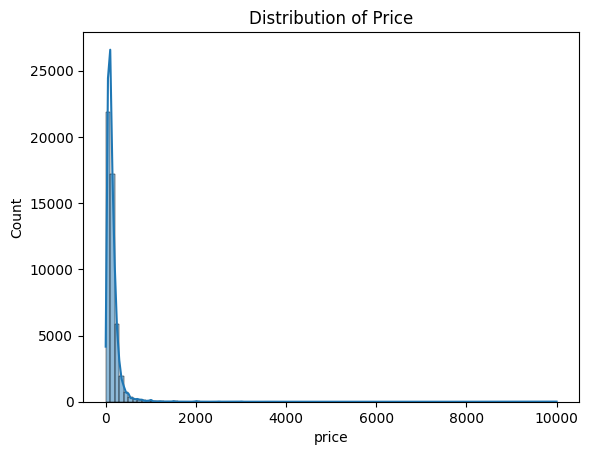

In [ ]:
print("\nSummary statistics:")
print(df.describe())

sns.histplot(df["price"], bins=100, kde=True)
plt.title("Distribution of Price")
plt.show()


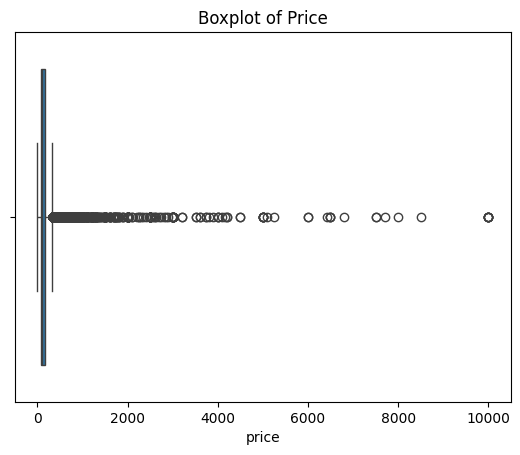

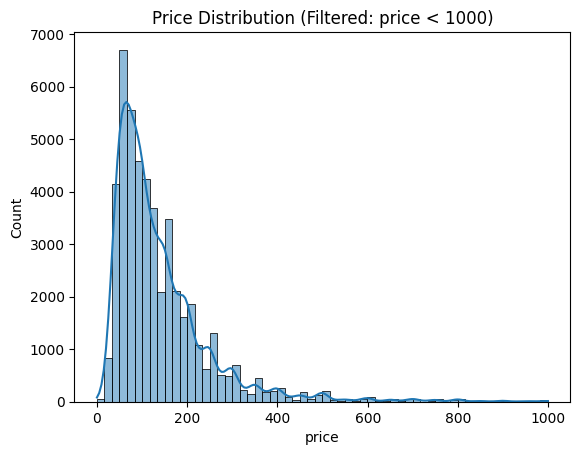

In [ ]:
sns.boxplot(x=df["price"])
plt.title("Boxplot of Price")
plt.show()

#filter out some extreme outliers
df_price_filtered = df[df["price"] < 1000]
sns.histplot(df_price_filtered["price"], bins=60, kde=True)
plt.title("Price Distribution (Filtered: price < 1000)")
plt.show()

We can see in this analysis that we see some skewness and outliers in the dataset. We see that the price variable is highly skewed and has some extreme values. We can see significant variability in listing prices. We can also conclude that we will nedd to handle outliers carefully.

###Strong skew in Price Dsitribution
In our historgram we see heavy concentration in listings in the lower price range (around the $50 to $200 dollar range) and we see a long tail trailing towards the high price range. This indicates that data isnt normally distributed and we might need to do some transformation (like log transformation of price) and tree baes models are better for analysis.

###Extreme Outliers

In our boxplot we see a lot of outliers, we some listings priced as high as 10,000 dollars. This either means there these listing are either super luxurious or do not represent typical Airbnb behavior. This will heavily impact linear models and our models may overestimate prices if we dont handle these outliers immediatley. If we don't want to use linear model (which are more sensitive to outlier) we can use tree-based models

We can handle these outliers by removing them or applying transformations.

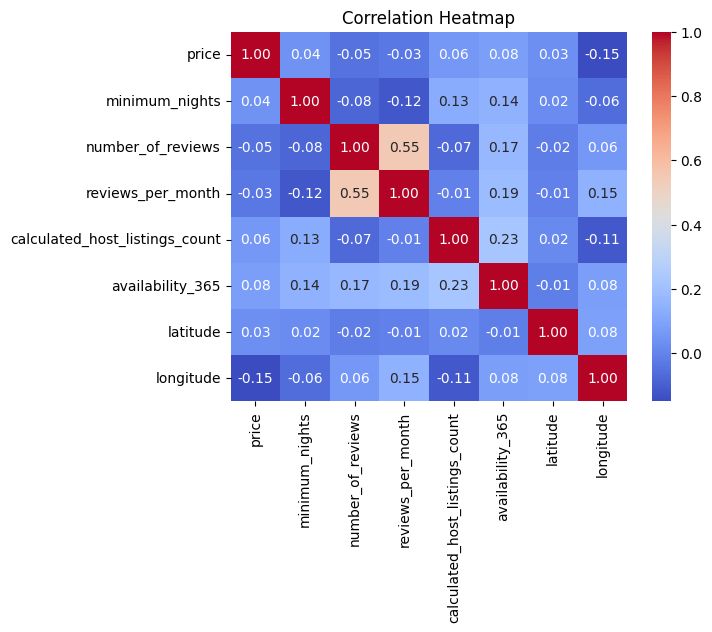

In [ ]:
numeric_cols = [
    "price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "latitude",
    "longitude"
]

corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

We see a weak correlation between price and features which indicates that there is no strong linear relationship between price and numerical features. This suggests that price might be more influences by complext nonlinear interactions

This further supports that we should use tree based models rather than linear models.

We see a strong correlation between reviews features, this means that listing that have more reviews have higher activity. This can introduce multicollinearity in linear models, further supporting the claim that we should use tree based models


Room type counts:
room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64

Neighbourhood group counts:
neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373
Name: count, dtype: int64


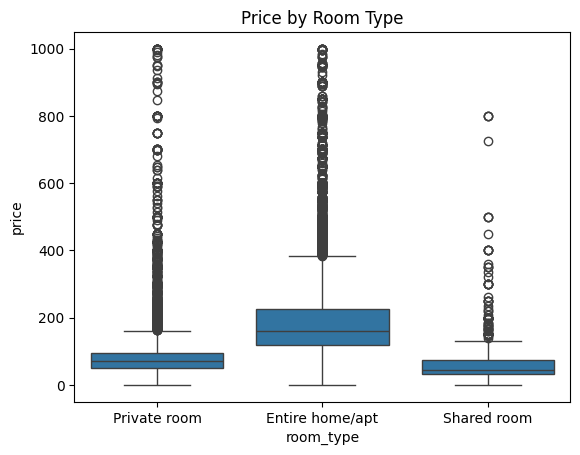

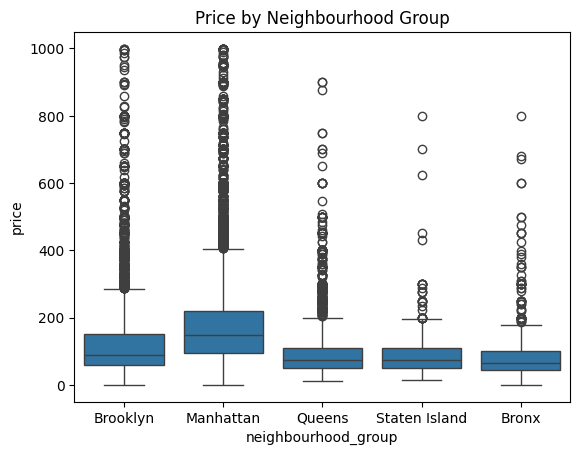


Average price by neighbourhood group:
neighbourhood_group
Manhattan        196.875814
Brooklyn         124.383207
Staten Island    114.812332
Queens            99.517649
Bronx             87.496792
Name: price, dtype: float64


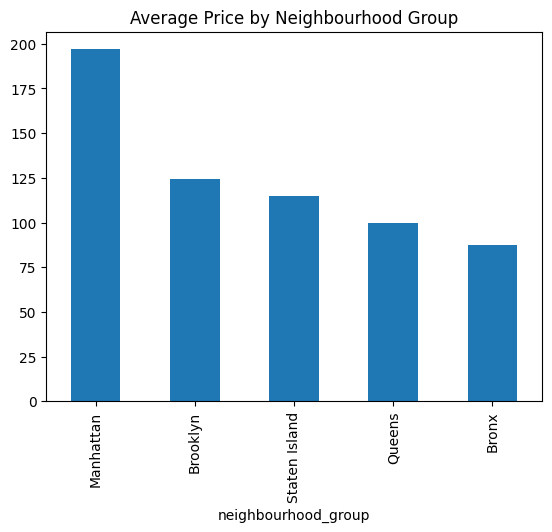

In [ ]:
#Categorical feature analysis
print("\nRoom type counts:")
print(df["room_type"].value_counts())

print("\nNeighbourhood group counts:")
print(df["neighbourhood_group"].value_counts())

sns.boxplot(data=df_price_filtered, x="room_type", y="price")
plt.title("Price by Room Type")
plt.show()

sns.boxplot(data=df_price_filtered, x="neighbourhood_group", y="price")
plt.title("Price by Neighbourhood Group")
plt.show()

avg_price_ng = df.groupby("neighbourhood_group")["price"].mean().sort_values(ascending=False)
print("\nAverage price by neighbourhood group:")
print(avg_price_ng)


avg_price_ng.plot(kind="bar")
plt.title("Average Price by Neighbourhood Group")
plt.show()

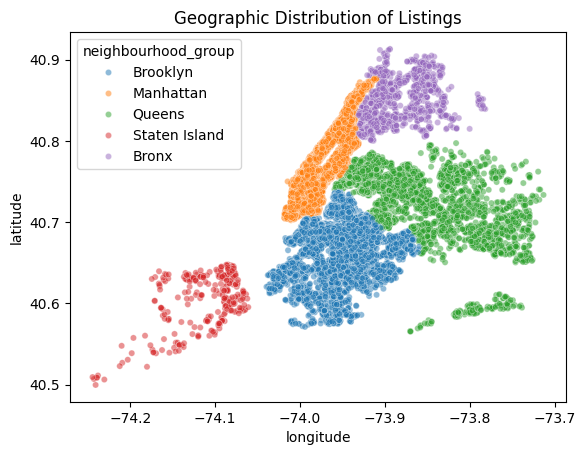

In [ ]:
sns.scatterplot(data=df, x="longitude", y="latitude", hue="neighbourhood_group", alpha=0.5, s=20)
plt.title("Geographic Distribution of Listings")
plt.show()

In this aalysis we see that Airbnb rnetals fall into the following types:
entire home/apt : 25409 listings
private room: 22326
shared room:  1,160

this just means that shared rooms are rare as they might be low in demand compared to entire homes/apartments or private rooms

From the boxplot we can also observe that share room has lowest prices which private rooms have moderate prices leaving entire homes/ apartments to have the highest prices. This means that entire homes/apartments have high variability and more extreme outliers and this confirms the importance of categorical features. This further supports that tree based models should be used as they will capture these splits effectively. We should use models like Random forest and Gradient Boosting to effectively capture the relationship between location, room type, and other features.



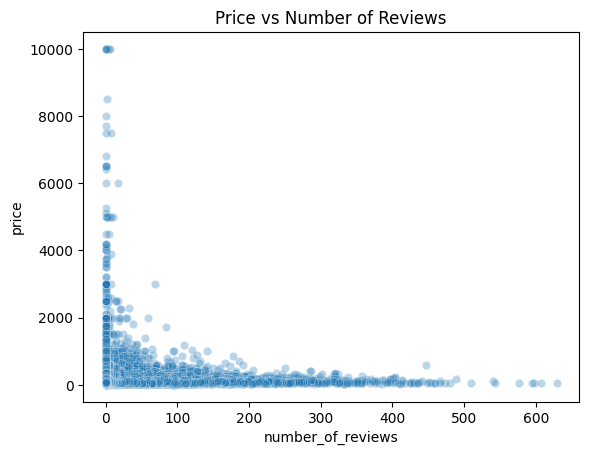

In [ ]:
sns.scatterplot(data=df, x="number_of_reviews", y="price", alpha=0.3)
plt.title("Price vs Number of Reviews")
plt.show()

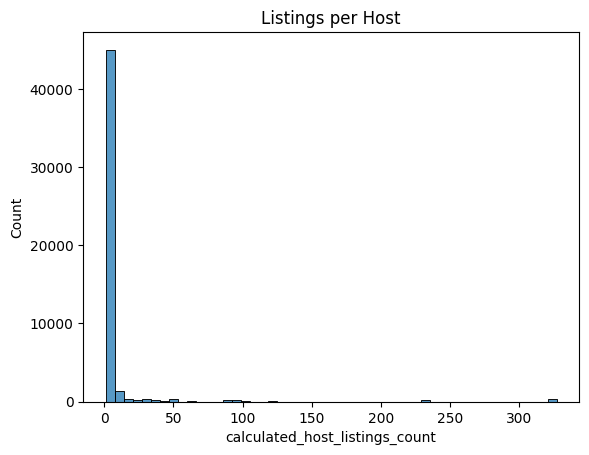

In [ ]:
sns.histplot(df["calculated_host_listings_count"], bins=50)
plt.title("Listings per Host")
plt.show()

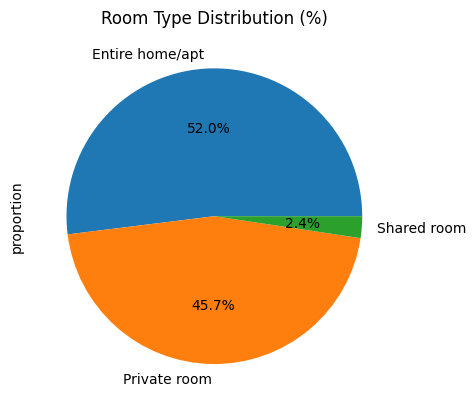

In [ ]:
df["room_type"].value_counts(normalize=True).plot(kind="pie", autopct="%1.1f%%")
plt.title("Room Type Distribution (%)")
plt.show()

In [ ]:
corr_target = df[numeric_cols].corr()["price"].sort_values(ascending=False)
print(corr_target)

price                             1.000000
availability_365                  0.081829
calculated_host_listings_count    0.057472
minimum_nights                    0.042799
latitude                          0.033939
reviews_per_month                -0.030608
number_of_reviews                -0.047954
longitude                        -0.150019
Name: price, dtype: float64


There is no strong linear relationship between price and any single numerical feature. Price is likely influenced by multiple features interacting together, rather than one dominant factor

Therefore, the correlation analysis shows that price does not have a strong linear relationship with any numerical feature, indicating that more complex, nonlinear models are needed to capture the underlying patterns.

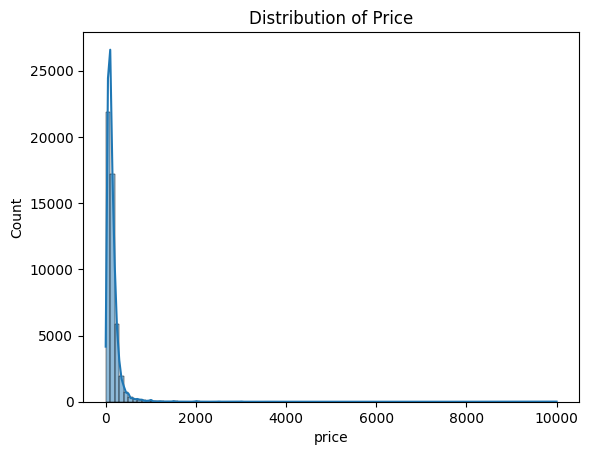

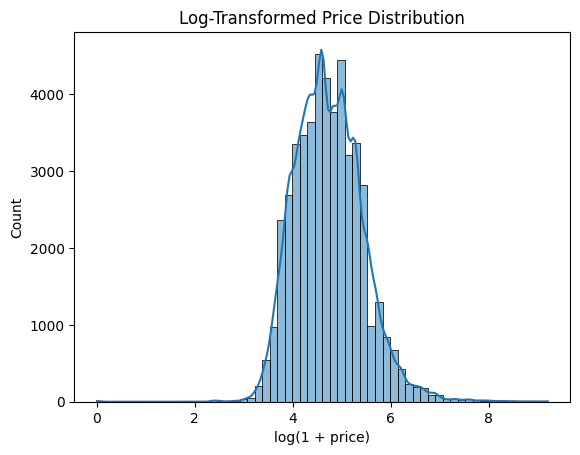

In [ ]:
sns.histplot(df["price"], bins=100, kde=True)
plt.title("Distribution of Price")
plt.show()
#log transformation for price
df["log_price"] = np.log1p(df["price"])
sns.histplot(df["log_price"], bins=60, kde=True)
plt.title("Log-Transformed Price Distribution")
plt.xlabel("log(1 + price)")
plt.show()


We applied a log transformation to price to help reduce skewness, and as show in the plot above we can see the vast improvement in the plots. We went from extremem skewness to a more normal distribution like plot whihc is more suitable for modeling.



Overall Eda reveals that our dataset needs some cleaning up to do, we need to deal with some outliers, missing values, and fix the weak relationship between numerical features and price. We saw from the geographic clustering that location plays a huge role in determining what price certain listings will be. Based on all these findings we can conclude that usuing nonlinear models like Randosm Forest and Gradient Boosting will yeild us the best results and simple linear models will not capture the comples interactions and handle the extreme outliers we saw.

##Data preprocessing

In this sectionwe will fix some inconsistencies in our data that we found in our exploratory data analysis section. For example we found missing values in last_review and reviews_per month. We see a strong skew in our target vairable, price (which we fixed with a log transformation).

In [ ]:
#make a copy of the dataset
df_model = df.copy()
#identify target (use log price)
df_model["log_price"] = np.log1p(df_model["price"])

#here we're going to remove unrealisitic values, anything greater than 100, this
#calculation comes from our distribution of price plort where the long tail starts around the value 1000
df_model = df_model[df_model["price"] < 1000]

#convert stringg to datetime object for pandas
df_model["last_review"] = pd.to_datetime(df_model["last_review"], errors="coerce")

max_date = df_model["last_review"].max()

df_model["days_since_last_review"] = (max_date - df_model["last_review"]).dt.days

In [ ]:
#filling missing reviews with 0 and -1
df_model["reviews_per_month"] = df_model["reviews_per_month"].fillna(0)
df_model["days_since_last_review"] = df_model["days_since_last_review"].fillna(-1)

#now we need to drop some features (target and identifiers)
features_to_drop = ["price", "log_price","id", "host_id","name", "host_name", "last_review"]

X = df_model.drop(columns=features_to_drop)
y = df_model["log_price"]

#distinguish between categorical and numerical variables
categorical_cols = ["neighbourhood_group", "neighbourhood", "room_type"]

numeric_cols = ["latitude", "longitude", "minimum_nights", "number_of_reviews",
                "reviews_per_month","calculated_host_listings_count",
                "availability_365", "days_since_last_review"]

Since observed many outliers and varying feature distributions in many of our plots for numerical and categorical data, we want to feature scale the variables. We are going to impute data for the Numerical features by using the median (median is more robust to outliers) so that we reduce the impact of the outliers we saw before. We also will encode categorical variables using one hot encoding  (so that the model can easily interpret categorical variables in numeric format)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))])

#combine the results
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)])


In [ ]:
from sklearn.model_selection import train_test_split

#now we will split the data 80% training 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

#check for shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

#fit + transform
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape:", X_test_processed.shape)

X_train shape: (38877, 11)
X_test shape: (9720, 11)
y_train shape: (38877,)
y_test shape: (9720,)
Processed X_train shape: (38877, 234)
Processed X_test shape: (9720, 234)


After preprocessing, the number of features increased significantly from 11 to 234 due to one-hot encoding of categorical variables. This transformation introduced high dimensionality into the dataset, which can impact model performance and makes tree-based models more suitable for capturing complex relationships.

###After thoughts

After completing some data preprocessing, we then splits our data (80% training 20% testing) and printed out the shapes /processed data shapes to see if the one-hot encoding and feature scaling had any affect on our data. In this section we filled missing values, imputed and encode our numerical and categorical data while taking care of outliers.

## Model Building

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=10),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=10),
    "Gradient Boosting": GradientBoostingRegressor(random_state=10)
}

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

results = {}

for name, model in models.items():
    # Train model
    model.fit(X_train_processed, y_train)

    # Predict
    y_pred = model.predict(X_test_processed)

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Store results
    results[name] = {
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }

    # Print results
    print(f"\n{name}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R2: {r2:.4f}")


Linear Regression
RMSE: 0.4436
MAE: 0.3278
R2: 0.5604

Decision Tree
RMSE: 0.5661
MAE: 0.4109
R2: 0.2841

Random Forest
RMSE: 0.4117
MAE: 0.2986
R2: 0.6213

Gradient Boosting
RMSE: 0.4208
MAE: 0.3089
R2: 0.6043


In [ ]:
import pandas as pd

results_df = pd.DataFrame(results).T
print("\nModel Comparison:")
print(results_df)



Model Comparison:
                       RMSE       MAE        R2
Linear Regression  0.443591  0.327849  0.560398
Decision Tree      0.566092  0.410944  0.284075
Random Forest      0.411732  0.298569  0.621276
Gradient Boosting  0.420845  0.308920  0.604326


In [ ]:
results_df.sort_values(by="RMSE")

,RMSE,MAE,R2
Random Forest,0.411732,0.298569,0.621276
Gradient Boosting,0.420845,0.308920,0.604326
Linear Regression,0.443591,0.327849,0.560398
Decision Tree,0.566092,0.410944,0.284075


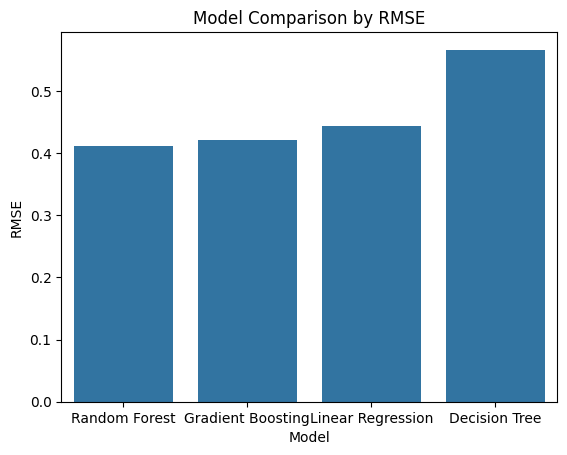

In [ ]:
#visualize model comparision

results_df = results_df.sort_values(by="RMSE")

sns.barplot(x=results_df.index, y=results_df["RMSE"])
plt.title("Model Comparison by RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.show()

###Random Forest (Best Model)
Random Forest achieved the best overall performance. This is expected because:

It handles nonlinear relationships well
It is robust to outliers, which we observed in the price distribution
It works effectively with high-dimensional data (234 features after encoding)

*  It handles nonlinear relationships well
*  It is robust to outliers, which we observed in the price distribution
*  It works effectively with high-dimensional data (234 features after encoding)

### Gradient Boosting (Close Second)

Gradient Boosting also performed well and was close to Random Forest.
It is a powerful model that:

*   Builds models sequentially to reduce errors
*   Captures complex patterns in the data

However, it slightly underperformed compared to Random Forest in this case.

### Linear Regression (Moderate Performance)

Linear Regression performed worse than the tree-based models. This aligns with our earlier EDA findings:

We observed weak linear correlations between price and numerical features
This means a linear model cannot fully capture the relationships in the data

###Decision Tree (Worst Model)

The Decision Tree model had the worst performance. This is likely because:

* It tends to overfit the training data
* It does not generalize well compared to ensemble methods like Random Forest

In [ ]:
# based off the fact that we picked Random Forest as our best model we wil perform
#some feature importance on it

best_model = models["Random Forest"]

feature_names = preprocessor.get_feature_names_out()

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance.head(15))

                                   Feature  Importance
231         cat__room_type_Entire home/apt    0.403152
1                           num__longitude    0.135087
0                            num__latitude    0.122736
6                    num__availability_365    0.063263
7              num__days_since_last_review    0.044309
2                      num__minimum_nights    0.043152
4                   num__reviews_per_month    0.041453
3                   num__number_of_reviews    0.034469
10      cat__neighbourhood_group_Manhattan    0.028218
5      num__calculated_host_listings_count    0.026758
140             cat__neighbourhood_Midtown    0.006479
232            cat__room_type_Private room    0.005278
233             cat__room_type_Shared room    0.003519
26   cat__neighbourhood_Bedford-Stuyvesant    0.002222
225        cat__neighbourhood_Williamsburg    0.001954


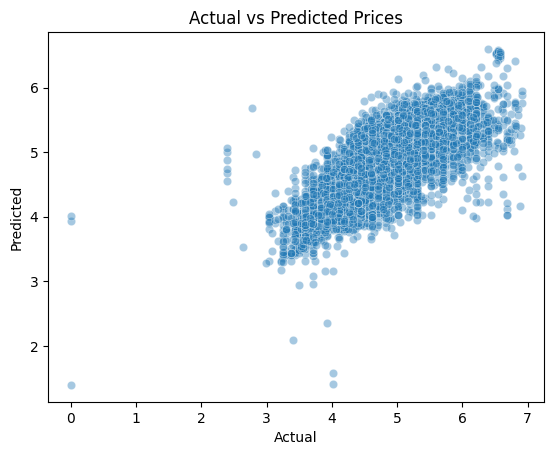

In [ ]:
y_pred = best_model.predict(X_test_processed)

sns.scatterplot(x=y_test, y=y_pred, alpha=0.4)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Prices")
plt.show()

To further analyze our best performing model we analyzed the prdiction accuracy and feature importance using the Random Forest Regressor.

In the actual vs predicted price scatterplot we see a positive relationship between true price and predicted price. This means that as the AirBnb prices increase the predicted prices is also increasing which indicated that model is good at capturing the pricing pattern. We do see a few outliers which may be true outlier or error, but this is expected bahvior from a housing dataset as there are many complex factors.

For feature importance, we see which variable have the most influence on price predictions. The most important predictor was Entire home/apartment room type (40.3%), while the second and third most important predictors were Longitude and Latitiude which indicated that location is very crutical in determining price for AirBnbs.

Overall in this analysis we found that room type and geogrpahic location plays a critical role in Airbnb price predicition. This aligns with our exploratory data analysis where we analyzed that room type and neighborhood was visally affecting price.